<a href="https://colab.research.google.com/github/Dragonfly12347/Dragonfly12347/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Dataset Shape: (307511, 122)
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...  

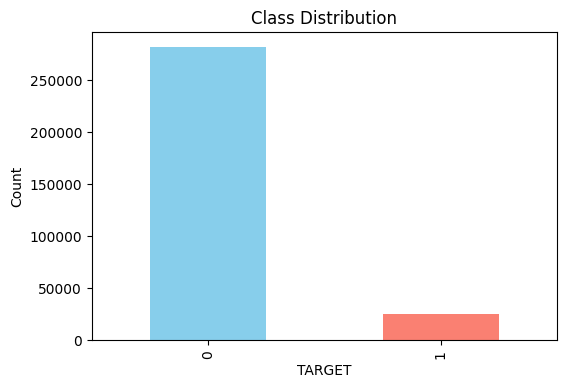

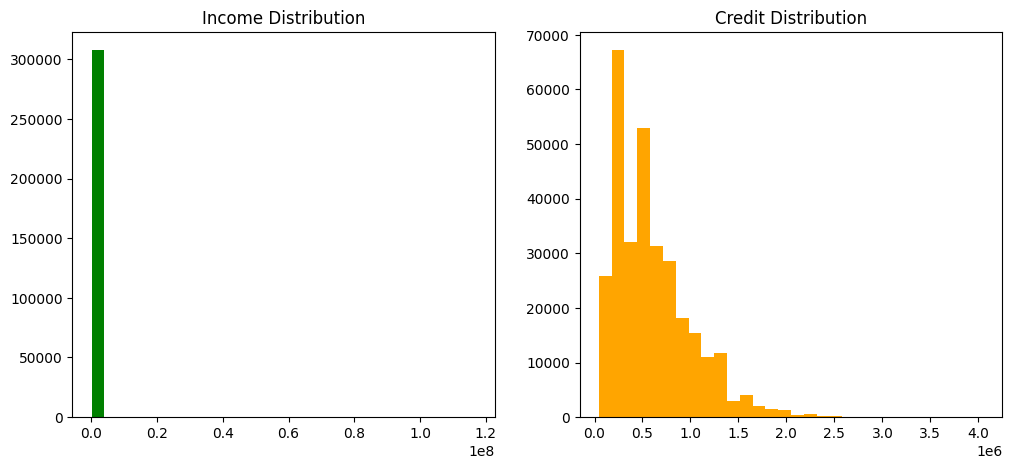

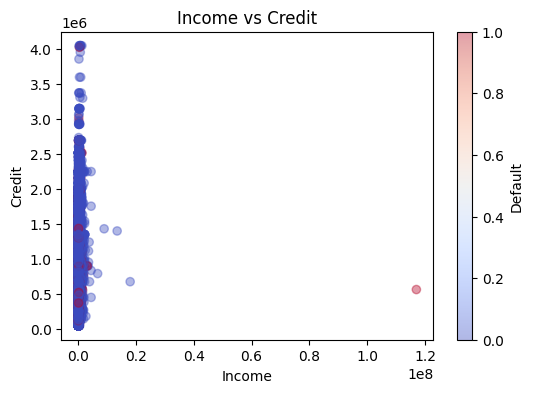


After SMOTE balancing:
TARGET
0    226132
1    226132
Name: count, dtype: int64


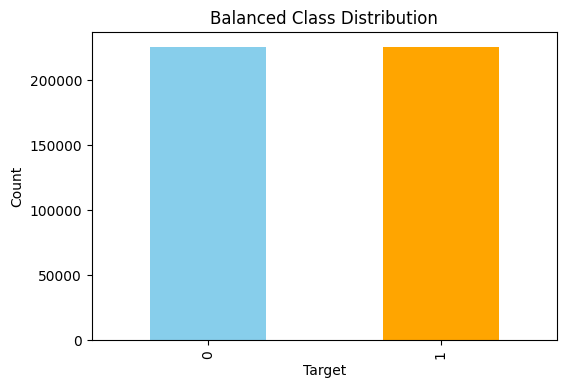


Best K: 2
KNN Accuracy: 0.8577955546883892
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     56554
           1       0.10      0.10      0.10      4949

    accuracy                           0.86     61503
   macro avg       0.51      0.51      0.51     61503
weighted avg       0.86      0.86      0.86     61503

Confusion Matrix:
[[52280  4274]
 [ 4472   477]]


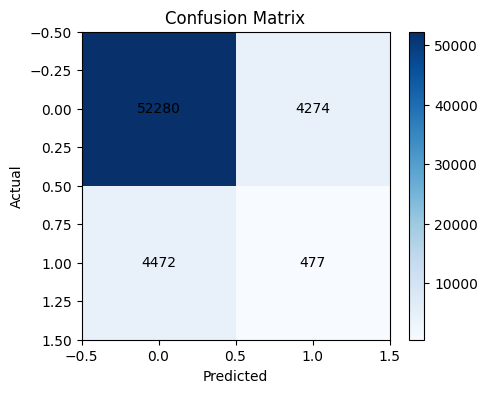

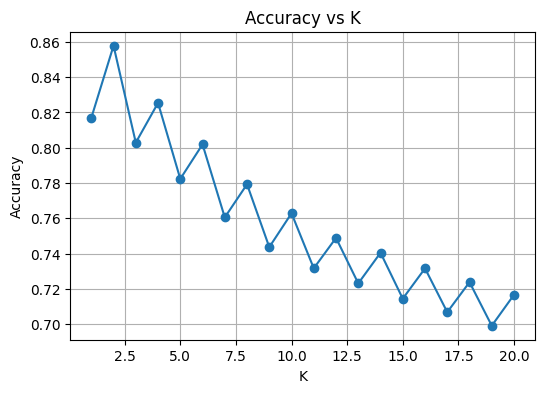

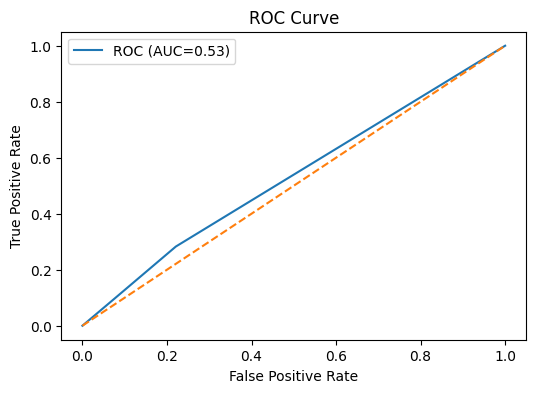

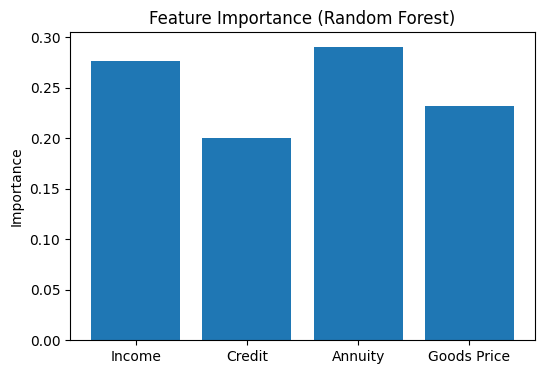


Model Comparison Results

Model: Logistic Regression
Accuracy: 0.4865941498788677
              precision    recall  f1-score   support

           0       0.94      0.47      0.63     56554
           1       0.09      0.63      0.16      4949

    accuracy                           0.49     61503
   macro avg       0.52      0.55      0.40     61503
weighted avg       0.87      0.49      0.59     61503

Confusion Matrix:
[[26820 29734]
 [ 1842  3107]]
-----------------------------------
Model: Decision Tree
Accuracy: 0.8188218460888087
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     56554
           1       0.13      0.21      0.16      4949

    accuracy                           0.82     61503
   macro avg       0.53      0.54      0.53     61503
weighted avg       0.86      0.82      0.84     61503

Confusion Matrix:
[[49325  7229]
 [ 3914  1035]]
-----------------------------------
Model: Random Forest
Accuracy: 0.8336016129

In [ ]:
# Credit Card Fraud Detection
# application_data.csv

# Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ML-Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.metrics import roc_curve,roc_auc_score

# Balancing
from imblearn.over_sampling import SMOTE


# Load dataset
df=pd.read_csv("application_data.csv")

print("Dataset Shape:",df.shape)
print(df.head())

print("\nTarget Distribution:")
print(df["TARGET"].value_counts())


# Graph 1: class distribution
plt.figure(figsize=(6,4))
df["TARGET"].value_counts().plot(kind="bar",color=["skyblue","salmon"])
plt.title("Class Distribution")
plt.xlabel("TARGET")
plt.ylabel("Count")
plt.show()


# Graph 2: Income and Credit
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df["AMT_INCOME_TOTAL"],bins=30,color="green")
plt.title("Income Distribution")

plt.subplot(1,2,2)
plt.hist(df["AMT_CREDIT"],bins=30,color="orange")
plt.title("Credit Distribution")

plt.show()


# Graph 3: Scatter
plt.figure(figsize=(6,4))
plt.scatter(df["AMT_INCOME_TOTAL"],df["AMT_CREDIT"],
            c=df["TARGET"],cmap="coolwarm",alpha=0.4)
plt.title("Income vs Credit")
plt.xlabel("Income")
plt.ylabel("Credit")
plt.colorbar(label="Default")
plt.show()


# Feature Selection
X=df[['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE']].fillna(0)
y=df["TARGET"]


# Scaling
scaler=StandardScaler()
X=scaler.fit_transform(X)


# Train test split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)


# Balance dataset
smote=SMOTE(random_state=42)
X_train,y_train=smote.fit_resample(X_train,y_train)

X_train=np.nan_to_num(X_train)
X_test=np.nan_to_num(X_test)

print("\nAfter SMOTE balancing:")
print(pd.Series(y_train).value_counts())


# Graph 4: balanced data
plt.figure(figsize=(6,4))
pd.Series(y_train).value_counts().plot(kind="bar",color=["skyblue","orange"])
plt.title("Balanced Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()


# Find Best K
accuracy_list=[]
k_range=range(1,21)

for k in k_range:
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    accuracy_list.append(accuracy_score(y_test,pred))

best_k=k_range[np.argmax(accuracy_list)]


# Train final KNN
knn=KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train,y_train)

y_pred=knn.predict(X_test)

print("\nBest K:",best_k)
print("KNN Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))


# Confusion Matrix
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)


# Graph 5: Confusion Matrix
plt.figure(figsize=(5,4))
plt.imshow(cm,cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j,i,cm[i,j],ha="center",va="center")

plt.colorbar()
plt.show()


# Graph 6: KNN Tuning
plt.figure(figsize=(6,4))
plt.plot(k_range,accuracy_list,marker="o")
plt.title("Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid()
plt.show()


# ROC Curve
y_prob=knn.predict_proba(X_test)[:,1]

fpr,tpr,thresholds=roc_curve(y_test,y_prob)

auc_score=roc_auc_score(y_test,y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr,tpr,label="ROC (AUC=%0.2f)"%auc_score)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# Feature importance
rf=RandomForestClassifier()
rf.fit(X_train,y_train)

importance=rf.feature_importances_

plt.figure(figsize=(6,4))
plt.bar(['Income','Credit','Annuity','Goods Price'],importance)
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.show()


# Model Comparison
models={
"Logistic Regression":LogisticRegression(max_iter=1000),
"Decision Tree":DecisionTreeClassifier(),
"Random Forest":RandomForestClassifier(),
"SVM":SVC(probability=True),
"Naive Bayes":GaussianNB(),
"KNN":knn
}

model_results={}

print("\nModel Comparison Results\n")

for name,model in models.items():
    model.fit(X_train,y_train)
    predictions=model.predict(X_test)
    acc=accuracy_score(y_test,predictions)
    model_results[name]=acc

    print("Model:",name)
    print("Accuracy:",acc)
    print(classification_report(y_test,predictions))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test,predictions))
    print("-----------------------------------")


# Graph 7: Model Accuracy
plt.figure(figsize=(8,5))
plt.bar(model_results.keys(),model_results.values())
plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()